In [1]:
import pandas as pd

In [2]:
train_df=pd.read_csv('/Users/apple/Downloads/data.csv')

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            430 non-null    object 
 1   Gender             420 non-null    object 
 2   Married            427 non-null    object 
 3   Dependents         416 non-null    object 
 4   Education          430 non-null    object 
 5   Self_Employed      410 non-null    object 
 6   ApplicantIncome    430 non-null    int64  
 7   CoapplicantIncome  430 non-null    float64
 8   LoanAmount         414 non-null    float64
 9   Loan_Amount_Term   422 non-null    float64
 10  Credit_History     394 non-null    float64
 11  Property_Area      430 non-null    object 
 12  Loan_Status        430 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 43.8+ KB


In [9]:
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,Y
1,LP001385,Male,No,0,Graduate,No,5316,0.0,136.0,360.0,1.0,Urban,Y
2,LP001926,Male,Yes,0,Graduate,No,3704,2000.0,120.0,360.0,1.0,Rural,Y
3,LP001144,Male,Yes,0,Graduate,No,5821,0.0,144.0,360.0,1.0,Urban,Y
5,LP001367,Male,Yes,1,Graduate,No,3052,1030.0,100.0,360.0,1.0,Urban,Y


In [10]:
train_df['Gender']= train_df['Gender'].map({'Male':0, 'Female':1})
train_df['Married']= train_df['Married'].map({'No':0, 'Yes':1})
train_df['Loan_Status']= train_df['Loan_Status'].map({'N':0, 'Y':1})

train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 335 entries, 0 to 429
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            335 non-null    object 
 1   Gender             335 non-null    int64  
 2   Married            335 non-null    int64  
 3   Dependents         335 non-null    object 
 4   Education          335 non-null    object 
 5   Self_Employed      335 non-null    object 
 6   ApplicantIncome    335 non-null    int64  
 7   CoapplicantIncome  335 non-null    float64
 8   LoanAmount         335 non-null    float64
 9   Loan_Amount_Term   335 non-null    float64
 10  Credit_History     335 non-null    float64
 11  Property_Area      335 non-null    object 
 12  Loan_Status        335 non-null    int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 36.6+ KB


In [11]:
train_df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [12]:
train_df=train_df.dropna()

In [13]:
train_df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
X = train_df[['Gender', 'Married', 'ApplicantIncome', 'LoanAmount', 'Credit_History']]
y = train_df.Loan_Status
X.shape, y.shape

((335, 5), (335,))

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=5)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=4, random_state=5)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, random_state=5)

In [17]:

from sklearn.metrics import accuracy_score

pred_val = model.predict(X_val)
accuracy_score(y_val, pred_val)

0.7313432835820896

In [18]:
!pip install mlflow

In [19]:
import mlflow

In [20]:
# Create a new MLflow Experiment
mlflow.set_experiment("Loan Status Tracking")

<Experiment: artifact_location='file:///Users/apple/Desktop/July25_Flask_Web_App/mlruns/116799540299934451', creation_time=1755707243816, experiment_id='116799540299934451', last_update_time=1755707243816, lifecycle_stage='active', name='Loan Status Tracking', tags={}>

In [21]:
# Start an MLflow run
with mlflow.start_run():
    
    model = RandomForestClassifier(max_depth=5, random_state=5)
    model.fit(X_train, y_train)
    
    pred_val = model.predict(X_val)
    test_acc= accuracy_score(y_val, pred_val)

    mlflow.set_tag('mlflow.runName', 'first_run')

    mlflow.log_param('max_depth',5)

    mlflow.log_metric ('test_acc', test_acc)

    model_info= mlflow.sklearn.log_model(sk_model= model,name="rf_model")



    # Set a tag that we can use to remind ourselves what this model was for
    mlflow.set_logged_model_tags(
        model_info.model_id, {"Training Info": "Basic RF model for LOAN data"}
    )





    
   

2025/08/20 22:23:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [24]:
def mlflow_runs(n_est , max_dep, i):
    
    with mlflow.start_run():
    
        model = RandomForestClassifier(n_estimators=n_est,  max_depth=max_dep, random_state=5)
        model.fit(X_train, y_train)
        
        pred_val = model.predict(X_val)
        test_acc= accuracy_score(y_val, pred_val)
    
        run="hyperparameter_run_"+str(i)
        mlflow.set_tag('mlflow.runName', run)
    
        mlflow.log_param('max_depth',max_dep)
        mlflow.log_param('Estimators',n_est)
    
        mlflow.log_metric ('test_acc', test_acc)
    
        model_info= mlflow.sklearn.log_model(sk_model= model,name="rf_model")
    
    
    
        # Set a tag that we can use to remind ourselves what this model was for
        mlflow.set_logged_model_tags(
            model_info.model_id, {"Training Info": "Basic RF model for LOAN data"}
        )

    

In [25]:
mlflow_runs(10,2,1)
mlflow_runs(20,2,2)
mlflow_runs(40,2,3)
mlflow_runs(10,4,4)
mlflow_runs(20,4,5)
mlflow_runs(40,4,6)
mlflow_runs(10,8,7)
mlflow_runs(20,8,8)
mlflow_runs(40,8,9)

2025/08/20 22:23:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/08/20 22:23:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/08/20 22:23:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/08/20 22:24:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/08/20 22:24:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/08/20 22:24:04 

In [27]:
!mlflow ui --port 5001

INFO:     Uvicorn running on http://127.0.0.1:5001 (Press CTRL+C to quit)
INFO:     Started parent process [80188]
INFO:     Started server process [80193]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Started server process [80191]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     127.0.0.1:63006 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:63006 - "GET /static-files/static/js/main.e1ed6ef5.js HTTP/1.1" 200 OK
INFO:     127.0.0.1:63003 - "GET /static-files/static/css/main.702595df.css HTTP/1.1" 200 OK
INFO:     Started server process [80190]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Started server process [80192]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     127.0.0.1:63006 - "GET /static-files/static/js/9478.cbf55ef3.chunk.js HTTP/1.1" 200 OK
INFO:     127.0.0.1:63006 - "GET /static-files/static/js

2025/08/20 22:44:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


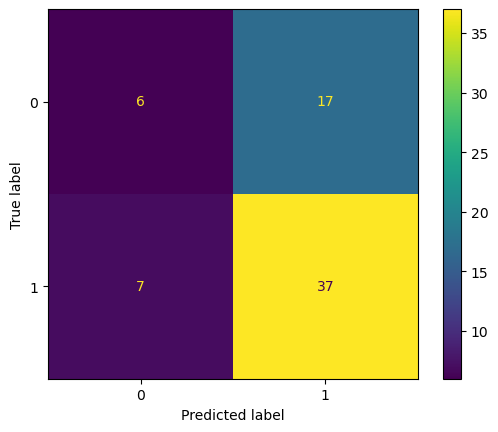

In [28]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

with mlflow.start_run():
    
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train, y_train)
    
    pred_val = knn_model.predict(X_val)
    test_acc= accuracy_score(y_val, pred_val)

    run="KNN"
    mlflow.set_tag('mlflow.runName', run)

    mlflow.log_param('nneighbors',5)
    

    mlflow.log_metric ('test_acc', test_acc)

    model_info= mlflow.sklearn.log_model(sk_model= knn_model,name="KNN_MODEL")

    cm=ConfusionMatrixDisplay.from_predictions(y_val, pred_val)

    cm.figure_.savefig('confmat.png')

    mlflow.log_artifact('confmat.png')


    # Set a tag that we can use to remind ourselves what this model was for
    mlflow.set_logged_model_tags(
        model_info.model_id, {"Training Info": "Basic KNN model for LOAN data"}
    )




In [29]:
!mlflow ui --port 5001

INFO:     Uvicorn running on http://127.0.0.1:5001 (Press CTRL+C to quit)
INFO:     Started parent process [80756]
INFO:     Started server process [80760]
INFO:     Waiting for application startup.
INFO:     Started server process [80761]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Application startup complete.
INFO:     Started server process [80759]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Started server process [80758]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     127.0.0.1:63756 - "GET / HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:63759 - "GET /ajax-api/2.0/mlflow/experiments/get?experiment_id=116799540299934451 HTTP/1.1" 200 OK
INFO:     127.0.0.1:63760 - "POST /ajax-api/2.0/mlflow/experiments/search-datasets HTTP/1.1" 200 OK
INFO:     127.0.0.1:63758 - "POST /ajax-api/2.0/mlflow/runs/search HTTP/1.1" 200 OK
INFO:     127.0.0.1:637